# **🔍 Recomendaciones Búsqueda y Estructura del Dataset:**




🛑 ✋ Antes de Iniciar! Ten en cuenta las siguientes recomendaciones a la hora de buscar tu dataset

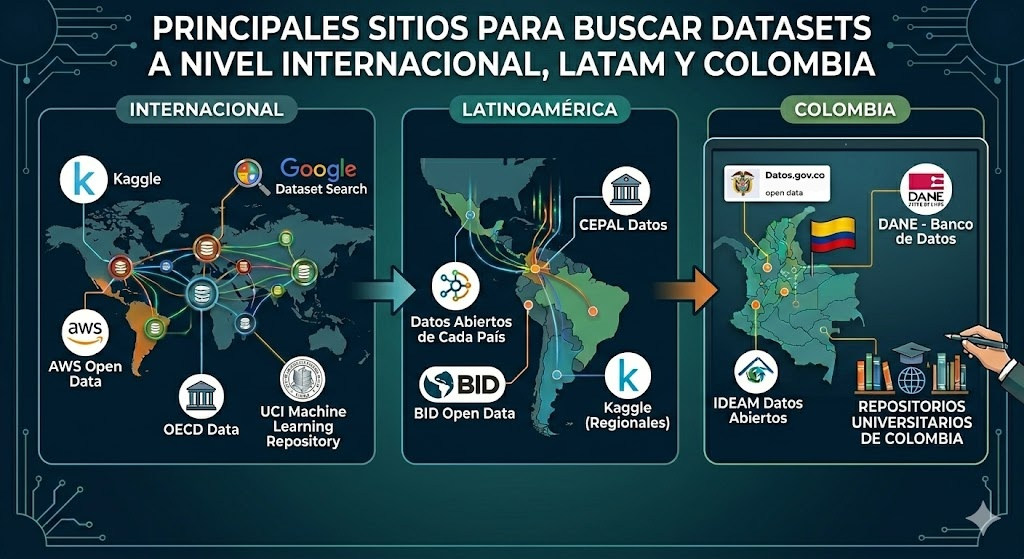

Fuente Imagen: Generada con Gemini

Usa bases de datos, plataformas o fuentes confiables, como:

https://www.kaggle.com/

https://huggingface.co/

https://datasetsearch.research.google.com/

https://github.com/

https://registry.opendata.aws/

https://www.oecd.org/en/data.html

https://archive.ics.uci.edu/datasets/

https://data.iadb.org/dataset/?type=dataset

https://statistics.cepal.org/portal/cepalstat/ (CEPAL: Comisión Económica para América Latina)

https://www.datos.gov.co/

https://www.dane.gov.co/

https://www.ideam.gov.co/transparencia/datos-abiertos

https://datosabiertos.bogota.gov.co/

https://medata.gov.co/

https://datosabiertos.metropol.gov.co/

**Repositorio Universitario**: Cada Universidad tiene acceso a Bases de Datos científicas donde se pueden encontrar variedad de datasets



##**Estructura Dataset:**

Debes tener en cuenta esta estructura para el dataset. Principalmente, la variable objetivo que debe ser númerica (para problemas de regresión) y tener una causalidad (inicialmente lógica) con las features o variables independientes.






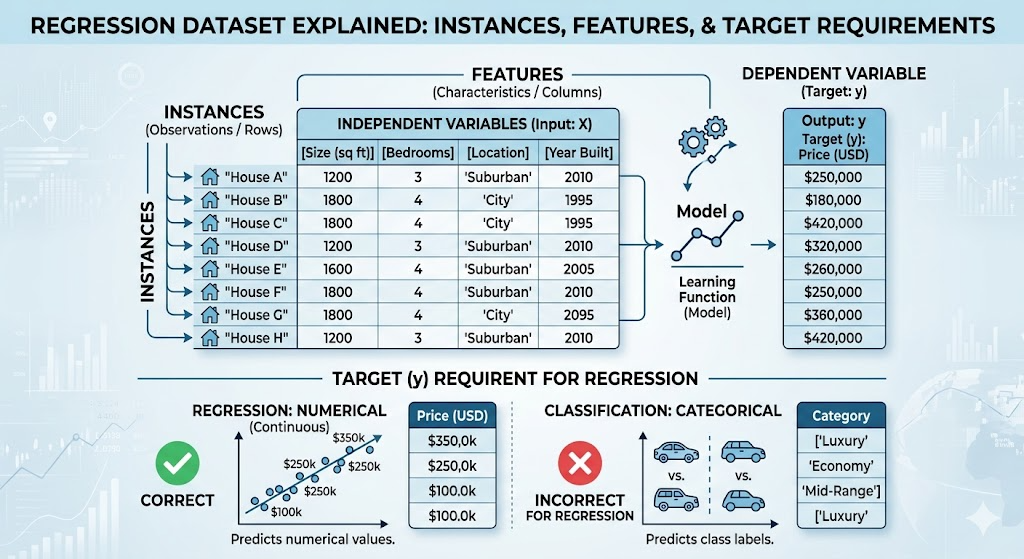

Fuente Imagen: Generada con Gemini

c# 📈 Puntuacion de Riesgo para aprobacion de Creditos

## Introducción:

**EDA**:

- Exploratory Data Analysis o Análisis Exploratorio de Datos, es la etapa inicial y crucial de cualquier proyecto de ciencia de datos o inteligencia artificial.
- Es el proceso donde "escuchamos lo que los datos tienen que decir" antes de aplicar algoritmos que generen el modelo de regresión.

✅ IMAGEN DEL DIAGRAMA DEL PASO A PASO DE MIROOO!!!!

**Objetivos:**

- **Académico**:

  Practicar por medio de la realización de un EDA para preparar los datos de un modelo de aprendizaje automático tipo regresión.

- **Consumidor**:
  
  Una persona que esté comparando dos vehículos similares puede usar estos datos para determinar cuál tendrá un menor costo operativo a largo plazo (basado en el consumo de combustible) y cuál es más amigable con el medio ambiente.

- **Organismos Gubernamentales y ONGs Ambientalistas**:
  - Políticas de emisiones: Para establecer estándares de eficiencia energética o proponer impuestos basados en el nivel de contaminación de ciertos segmentos de vehículos (como los SUV vs. Compactos).

  - Monitoreo de metas climáticas: Evaluar si las marcas de autos están reduciendo efectivamente sus emisiones promedio año tras año.

Fuente Imagen: Creada con ChatGPT

# 1. PIPELINE / CARGA DE DATOS E IMPORTACIÓN DE LIBRERÍAS

- **Pipeline** es un flujo de trabajo secuencial y automatizado que encadena todas las etapas del procesamiento de datos, desde la limpieza y el encoding durante el EDA, hasta el entrenamiento y la evaluación del modelo. Su función principal es garantizar la reproducibilidad y evitar la "fuga de datos" (data leakage), permitiendo que cualquier dato nuevo que ingrese al sistema reciba exactamente las mismas transformaciones que los datos de entrenamiento antes de generar una predicción, convirtiendo un proceso manual fragmentado en un sistema robusto y escalable.

- La **fuga de datos (data leakage)** es un error crítico en el que información del conjunto de prueba o datos que no estarían disponibles en el futuro se "filtran" inadvertidamente en el entrenamiento del modelo, provocando que este "haga trampa" al conocer las respuestas de antemano. Esto genera una falsa sensación de éxito con métricas de precisión artificialmente altas que se desploman al enfrentarse a datos reales, por lo que es fundamental separar estrictamente los datos de entrenamiento de los de prueba antes de cualquier proceso de limpieza o transformación.

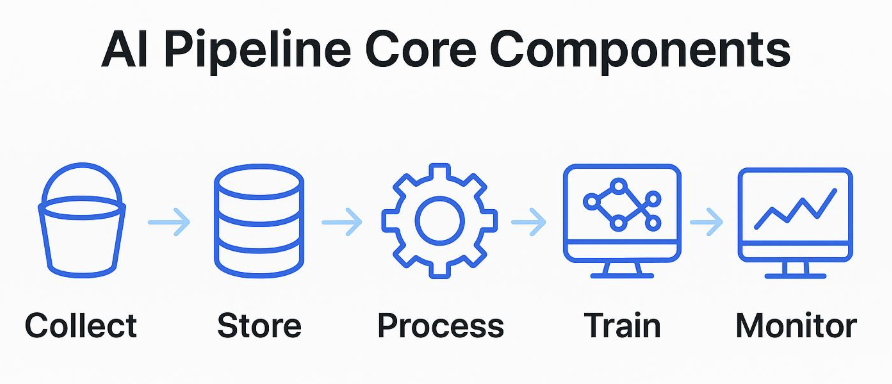

In [ ]:
!pip install category_encoders shap yellowbrick

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import shap
import category_encoders as ce

from scipy import stats
from scipy.stats import skew, boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from yellowbrick.regressor import ResidualsPlot, PredictionError
from category_encoders import TargetEncoder
from ipywidgets import interact

warnings.filterwarnings("ignore")

In [ ]:
# Forma 2)

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1CYEKxR8Hj6VoWSTMZjR4eoNtMzSuVpY7'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)
df

#https://drive.google.com/file/d/1CYEKxR8Hj6VoWSTMZjR4eoNtMzSuVpY7/view?usp=sharing

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
AnnualIncome,20000.0,59161.473550,40350.845168,15000.000000,31679.000000,48566.000000,74391.000000,4.853410e+05
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01


In [ ]:
df.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,0
EmploymentStatus,0
EducationLevel,0
Experience,0
LoanAmount,0
LoanDuration,0
MaritalStatus,0


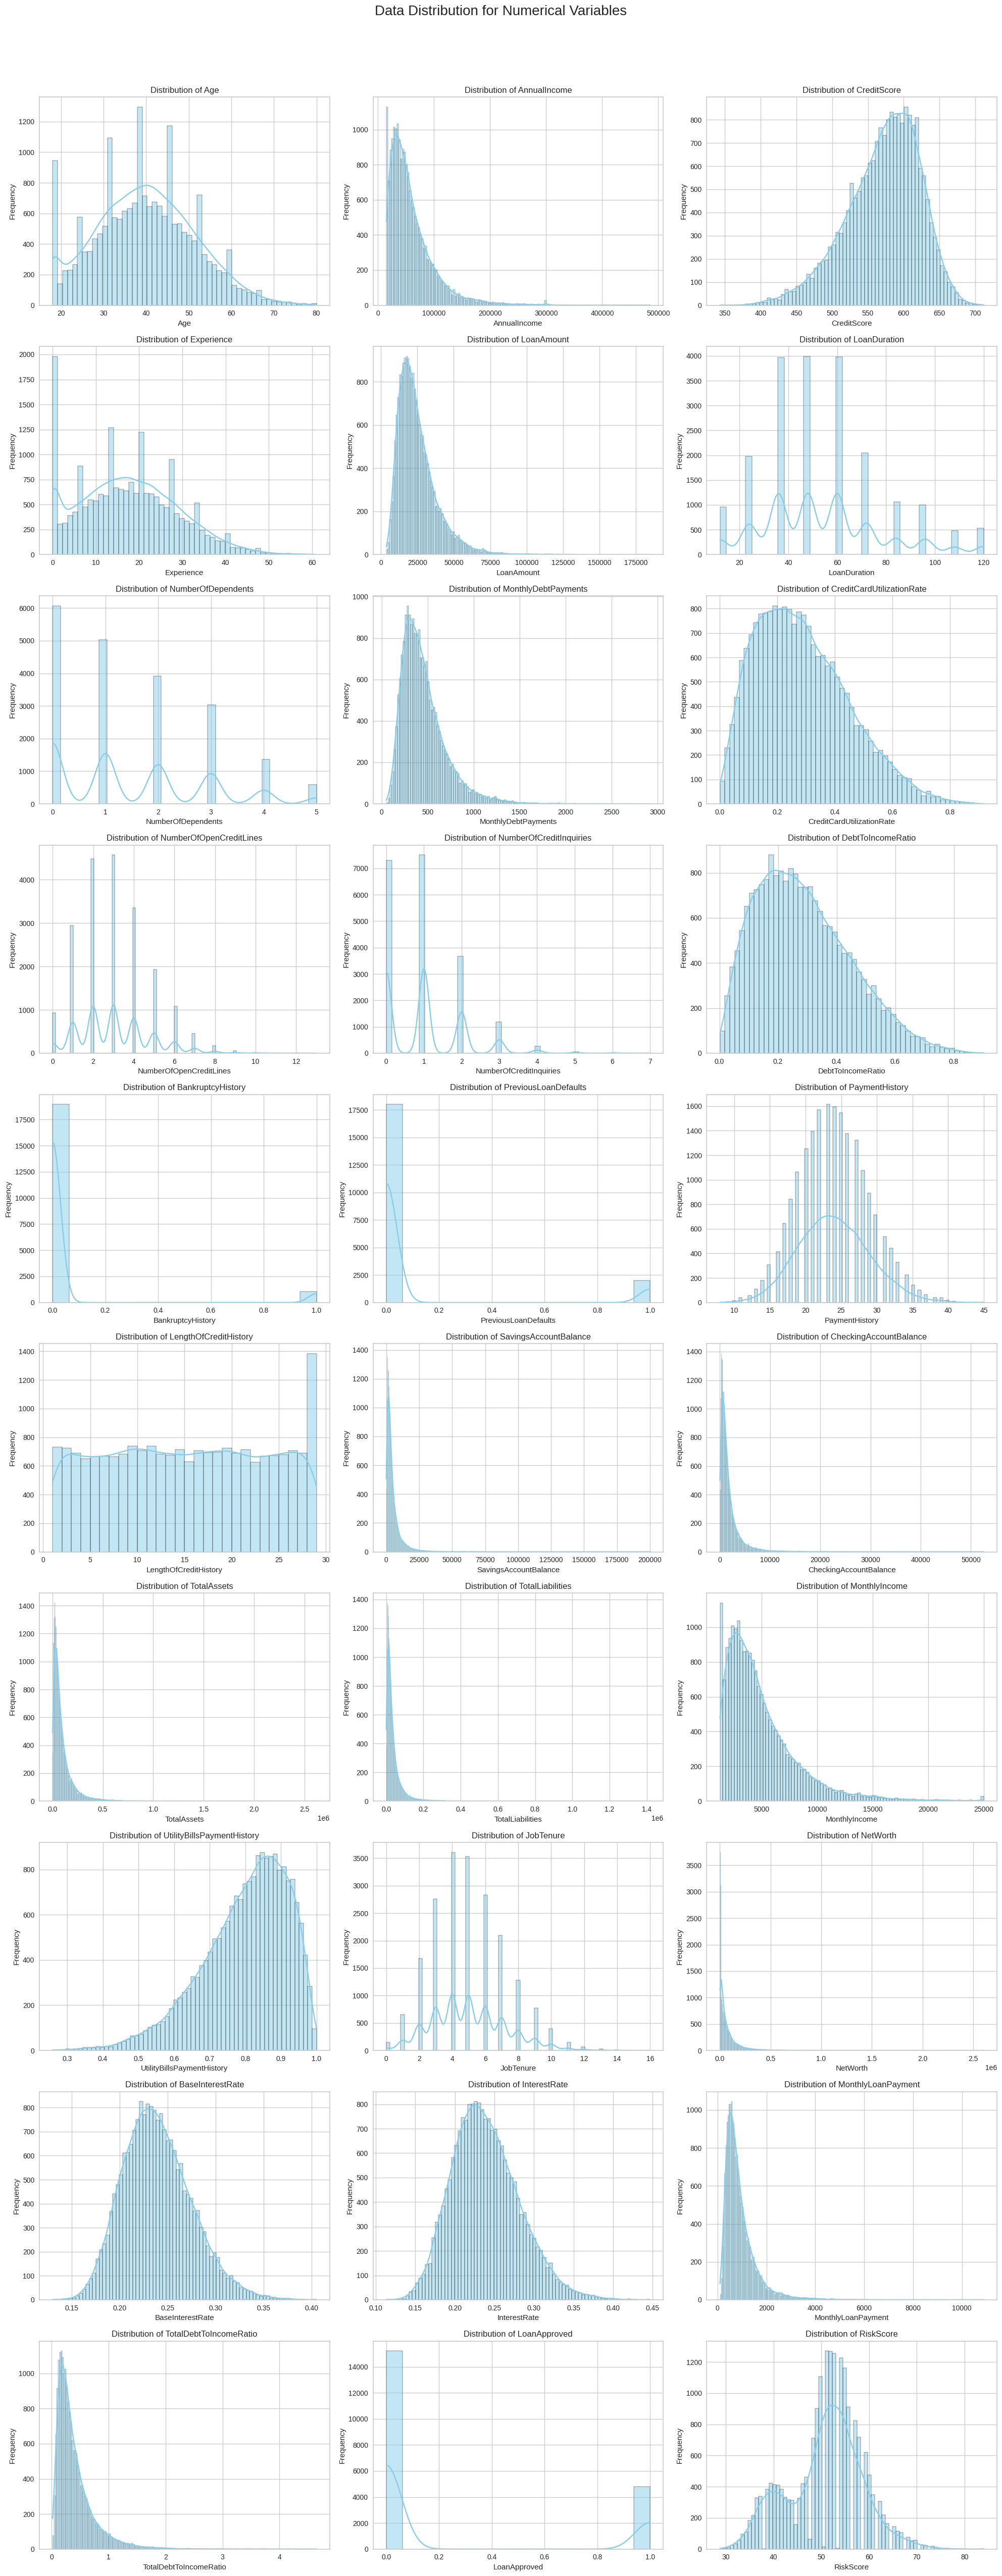

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Filter numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate grid size for subplots
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create the figure
plt.figure(figsize=(20, 5 * n_rows))
plt.suptitle('Data Distribution for Numerical Variables', fontsize=20, y=1.02)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

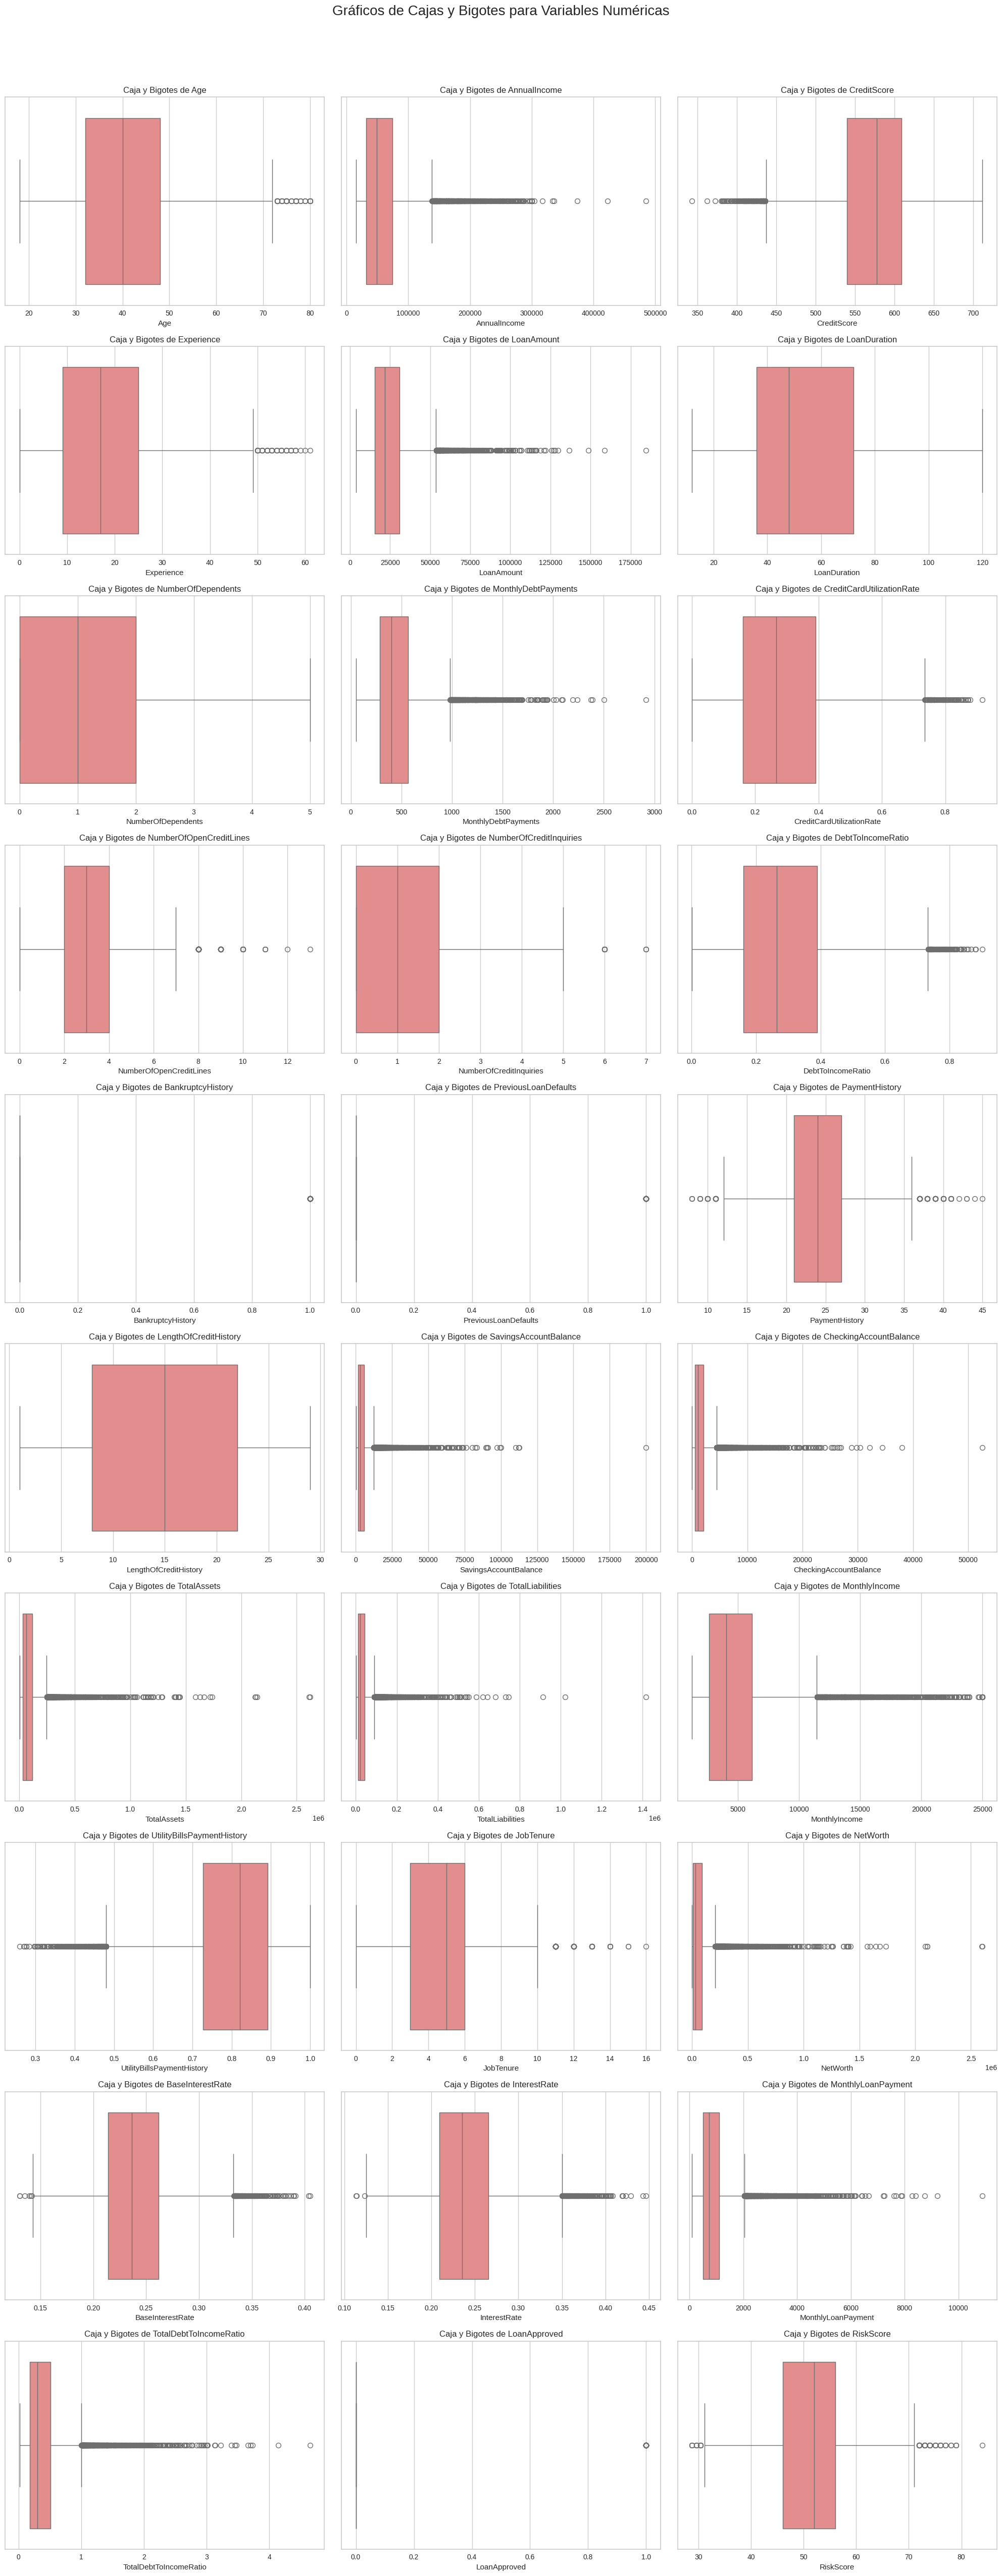

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Filtrar columnas numéricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calcular el tamaño de la cuadrícula
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Crear la figura para los diagramas de caja
plt.figure(figsize=(20, 5 * n_rows))
plt.suptitle('Gráficos de Cajas y Bigotes para Variables Numéricas', fontsize=20, y=1.02)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Caja y Bigotes de {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

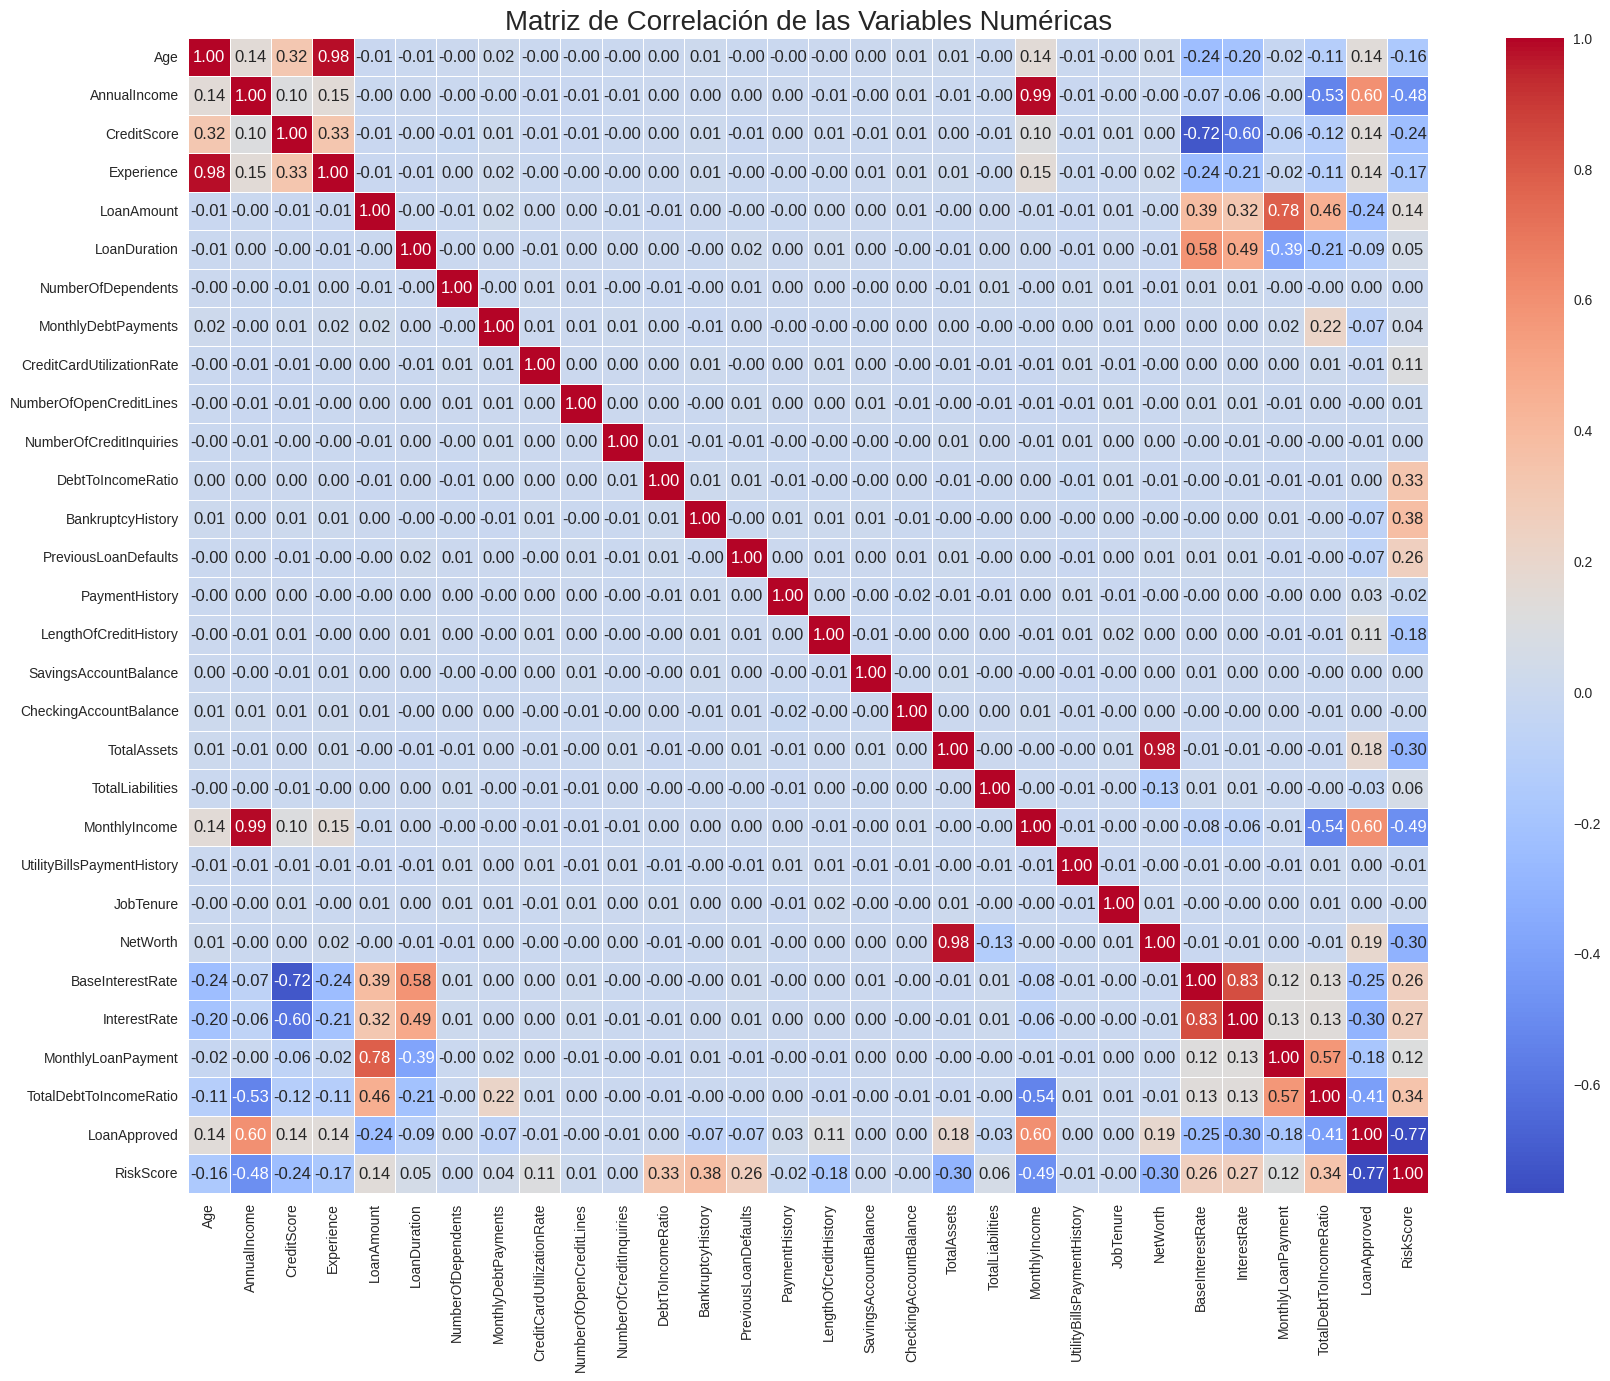

In [ ]:
# Calcular la matriz de correlación para variables numéricas
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Configurar el tamaño de la figura
plt.figure(figsize=(20, 15))

# Crear el mapa de calor (heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación de las Variables Numéricas', fontsize=20)
plt.show()

In [ ]:
# 1. Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'ApplicationDate' in categorical_cols: categorical_cols.remove('ApplicationDate')

# 2. Label Encoding
df_label = df.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_label[col] = le.fit_transform(df_label[col].astype(str))

# 3. One-Hot Encoding
df_ohe = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Target Encoding (usando RiskScore como objetivo)
te = TargetEncoder(cols=categorical_cols)
df_target = te.fit_transform(df, df['RiskScore'])

print(f"Codificaciones realizadas para: {categorical_cols}")
print("Dataframes creados: df_label, df_ohe, df_target.")
df_target.head()

Codificaciones realizadas para: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
Dataframes creados: df_label, df_ohe, df_target.


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,50.351104,49.073049,22,13152,48,50.735843,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,50.351104,51.342588,15,26045,48,50.889668,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,50.351104,50.325140,26,17627,36,50.735843,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,50.351104,52.214421,34,37898,96,50.889668,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,50.351104,51.342588,17,9184,36,50.735843,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


### **¿Cuál es el mejor método para este dataset?**

Para este dataset de **Puntuación de Riesgo**, la mejor opción es una combinación de técnicas:

1.  **One-Hot Encoding**: Es el mejor para variables como `MaritalStatus` o `HomeOwnershipStatus` porque tienen pocas categorías y no tienen un orden lógico. Esto evita que el modelo asuma que una categoría es 'mayor' que otra.
2.  **Ordinal Encoding (Manual)**: Para `EducationLevel`, lo ideal sería asignar valores numéricos que reflejen el nivel (ej. High School=1, Bachelor=2, etc.), ya que existe una jerarquía natural que ayuda al modelo.
3.  **Target Encoding**: Es muy útil si variables como `LoanPurpose` tuvieran muchas categorías (alta cardinalidad), ya que correlaciona directamente la categoría con el `RiskScore` promedio.

**Veredicto**: Si buscas simplicidad sin sesgar el modelo, el **One-Hot Encoding** es la opción más segura aquí. Si buscas maximizar la precisión, el **Target Encoding** suele ser el ganador en problemas de regresión de riesgo.

In [ ]:
df_target

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,50.351104,49.073049,22,13152,48,50.735843,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,50.351104,51.342588,15,26045,48,50.889668,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,50.351104,50.325140,26,17627,36,50.735843,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,50.351104,52.214421,34,37898,96,50.889668,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,50.351104,51.342588,17,9184,36,50.735843,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2072-09-29,44,30180,587,50.351104,52.214421,19,24521,36,50.735843,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,50.351104,51.342588,33,25818,36,50.735843,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,50.351104,50.325140,20,37033,72,50.735843,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,50.351104,52.214421,36,14760,72,50.735843,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


In [ ]:
# 1. Seleccionar columnas numéricas para escalar (excluyendo el objetivo y la fecha)
cols_to_scale = df_target.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'RiskScore' in cols_to_scale: cols_to_scale.remove('RiskScore')

# 2. Aplicar StandardScaler
scaler = StandardScaler()
df_scaled = df_target.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

print(f"Escalamiento completado para {len(cols_to_scale)} columnas.")
df_scaled.head()

Escalamiento completado para 34 columnas.


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,0.451489,-0.476172,0.890021,-0.40087,-1.312413,0.395637,-0.873672,-0.245578,-0.234653,...,-0.474026,-0.621121,2.681281,0.463323,-1.111623,-0.272968,-0.729062,-0.652388,-0.560411,49.0
1,2018-01-02,-0.150795,-0.482095,1.105724,-0.40087,0.446174,-0.222926,0.086551,-0.245578,0.932086,...,-0.480067,1.120606,-0.895340,-0.243267,-0.903420,-0.901165,-0.174264,-0.036378,-0.560411,52.0
2,2018-01-03,0.623571,-0.456940,-0.031618,-0.40087,-0.342211,0.749102,-0.540390,-0.732113,-0.234653,...,-0.454410,0.599385,0.445893,-0.568953,-0.605407,-0.629370,-0.363493,0.176962,-0.560411,52.0
3,2018-01-04,1.570017,0.245912,-0.521852,-0.40087,1.121727,1.456031,0.969319,1.700559,0.932086,...,0.262471,0.797576,-0.001185,0.230312,1.725605,1.464331,0.201463,-0.262848,-0.560411,54.0
4,2018-01-05,-0.236835,1.093004,0.439006,-0.40087,0.446174,-0.046193,-1.169194,-0.732113,-0.234653,...,1.126469,1.172293,-0.001185,1.312148,-1.181127,-1.495584,-0.861928,-0.979511,1.784405,36.0


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 1. Preparación de variables
X = df_scaled.drop(columns=['RiskScore', 'ApplicationDate'])
y = df_scaled['RiskScore']

split_ratios = [0.30, 0.25, 0.20]
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

results_list = []

for test_size in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    split_name = f"{int((1-test_size)*100)}-{int(test_size*100)}"

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results_list.append({
            'Split': split_name,
            'Model': name,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    # Caso especial: Regresión Polinómica (Grado 2)
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model = LinearRegression().fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)

    mse_poly = mean_squared_error(y_test, y_pred_poly)
    results_list.append({
        'Split': split_name,
        'Model': 'Polynomial (Deg 2)',
        'MSE': mse_poly,
        'RMSE': np.sqrt(mse_poly),
        'MAE': mean_absolute_error(y_test, y_pred_poly),
        'R2': r2_score(y_test, y_pred_poly)
    })

# 2. Resumen de resultados
df_results = pd.DataFrame(results_list)
pd.set_option('display.max_rows', None)
print("Tabla resumen de experimentos actualizada:")
display(df_results.sort_values(by=['R2'], ascending=False))

Tabla resumen de experimentos actualizada:


,Split,Model,MSE,RMSE,MAE,R2
26,80-20,Gradient Boosting,0.335509,0.579231,0.419649,0.994596
16,75-25,Gradient Boosting,0.340297,0.583350,0.424643,0.994487
6,70-30,Gradient Boosting,0.356070,0.596716,0.430525,0.994183
25,80-20,Random Forest,0.884943,0.940714,0.589199,0.985747
15,75-25,Random Forest,0.907003,0.952367,0.599487,0.985305
5,70-30,Random Forest,0.942179,0.970659,0.614026,0.984608
24,80-20,Decision Tree,1.959210,1.399718,0.794450,0.968444
29,80-20,Polynomial (Deg 2),1.992974,1.411727,1.080362,0.967901
4,70-30,Decision Tree,2.044920,1.430007,0.811467,0.966593
14,75-25,Decision Tree,2.072632,1.439664,0.810680,0.966419


In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# 1. Entrenar el mejor modelo identificado (Gradient Boosting con el split 80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
best_model = GradientBoostingRegressor()
best_model.fit(X_train, y_train)

# 2. Función para procesar entradas y predecir
def predict_risk(age, income, credit_score, employment, education, loan_amount, tenure):
    # Crear un diccionario con una fila de ejemplo para mantener la estructura
    input_data = df.iloc[0:1].copy()

    # Actualizar valores con la entrada del usuario
    input_data['Age'] = age
    input_data['AnnualIncome'] = income
    input_data['CreditScore'] = credit_score
    input_data['EmploymentStatus'] = employment
    input_data['EducationLevel'] = education
    input_data['LoanAmount'] = loan_amount
    input_data['JobTenure'] = tenure

    # Aplicar Target Encoding (usando el objeto 'te' ya entrenado)
    input_df_te = te.transform(input_data)

    # Preparar para escalamiento (eliminar columnas no usadas)
    X_input = input_df_te.drop(columns=['RiskScore', 'ApplicationDate'])

    # Aplicar Escalamiento (usando el objeto 'scaler' ya entrenado)
    X_input_scaled = scaler.transform(X_input)

    # Predicción
    prediction = best_model.predict(X_input_scaled)[0]

    print(f"\n--- Resultado de la Predicción ---")
    print(f"Puntuación de Riesgo Estimada: {prediction:.2f}")

    # Interpretación simple
    if prediction < 45: status = "Bajo Riesgo"
    elif prediction < 60: status = "Riesgo Moderado"
    else: status = "Alto Riesgo"
    print(f"Categoría Sugerida: {status}")

# 3. Interfaz interactiva
print("Ajusta los parámetros para ver la predicción en tiempo real:")
interact(predict_risk,
         age=IntSlider(min=18, max=80, step=1, value=35),
         income=IntSlider(min=10000, max=200000, step=1000, value=50000),
         credit_score=IntSlider(min=300, max=850, step=1, value=600),
         employment=Dropdown(options=df['EmploymentStatus'].unique(), value='Employed'),
         education=Dropdown(options=df['EducationLevel'].unique(), value='Bachelor'),
         loan_amount=IntSlider(min=1000, max=100000, step=500, value=15000),
         tenure=IntSlider(min=0, max=40, step=1, value=5)
        );

Ajusta los parámetros para ver la predicción en tiempo real:


interactive(children=(IntSlider(value=35, description='age', max=80, min=18), IntSlider(value=50000, descripti…